# Ultra Pro: классификация эмоциональной речи

**Задача:** обучить классификатор эмоций на датасете **TESS** (Toronto Emotional Speech Set) с точностью на тесте ≥ 98%, затем проверить его на датасете **SAVEE** и сделать выводы.

**Подход:**
- Признаки: **мел-спектрограммы** (Conv2D отлично работает с ними для эмоций)
- Архитектура: свёрточная сеть с BatchNorm и Dropout
- Аугментация: добавление шума, сдвиги во времени (для лучшего обобщения)


## 1. Импорт библиотек

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gdown
import os
import time
import random
import pickle
import librosa
import librosa.display

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Input, Dense, Dropout, BatchNormalization,
                                     Flatten, Conv2D, MaxPooling2D, GlobalAveragePooling2D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## 2. Загрузка датасета TESS

In [ ]:
# Загрузка TESS
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l12/dataverse_files.zip',
               None, quiet=False)

# Распаковка
!unzip -qo dataverse_files.zip -d tess_data
!ls tess_data | head -20

Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l12/dataverse_files.zip
To: /content/dataverse_files.zip
100%|██████████| 224M/224M [00:16<00:00, 13.7MB/s]


MANIFEST.TXT
OAF_back_angry.wav
OAF_back_disgust.wav
OAF_back_fear.wav
OAF_back_happy.wav
OAF_back_neutral.wav
OAF_back_ps.wav
OAF_back_sad.wav
OAF_bar_angry.wav
OAF_bar_disgust.wav
OAF_bar_fear.wav
OAF_bar_happy.wav
OAF_bar_neutral.wav
OAF_bar_ps.wav
OAF_bar_sad.wav
OAF_base_angry.wav
OAF_base_disgust.wav
OAF_base_fear.wav
OAF_base_happy.wav
OAF_base_neutral.wav


## 3. Разбор структуры TESS

В TESS имя файла содержит эмоцию: `OAF_back_angry.wav` или `YAF_back_angry.wav`.
- `OAF` / `YAF` — Older/Younger Adult Female (актрисы)
- Слово
- Эмоция: angry, disgust, fear, happy, neutral, ps (pleasant_surprise), sad

In [ ]:
# Поиск всех .wav файлов
import glob

tess_files = []
for root, dirs, files in os.walk('tess_data'):
    for f in files:
        if f.lower().endswith('.wav'):
            tess_files.append(os.path.join(root, f))

print(f'Найдено wav-файлов: {len(tess_files)}')
print('Примеры:')
for p in tess_files[:5]:
    print(' ', p)

# Извлечение метки из имени файла
def parse_emotion_tess(filepath):
    name = os.path.basename(filepath).lower().replace('.wav', '')
    # Эмоция — последнее слово после последнего '_'
    parts = name.split('_')
    emotion = parts[-1]
    # Нормализация
    mapping = {
        'ps': 'pleasant_surprise',
        'surprise': 'pleasant_surprise',
        'surprised': 'pleasant_surprise',
        'angry': 'angry',
        'disgust': 'disgust',
        'fear': 'fear',
        'happy': 'happy',
        'neutral': 'neutral',
        'sad': 'sad'
    }
    return mapping.get(emotion, emotion)

# Собираем метки
tess_labels = [parse_emotion_tess(p) for p in tess_files]

# Распределение по эмоциям
from collections import Counter
print('\nРаспределение эмоций в TESS:')
for emo, cnt in sorted(Counter(tess_labels).items()):
    print(f'  {emo}: {cnt}')

Найдено wav-файлов: 2800
Примеры:
  tess_data/OAF_laud_angry.wav
  tess_data/YAF_kite_fear.wav
  tess_data/OAF_gaze_ps.wav
  tess_data/YAF_fail_sad.wav
  tess_data/OAF_yearn_happy.wav

Распределение эмоций в TESS:
  angry: 400
  disgust: 400
  fear: 400
  happy: 400
  neutral: 400
  pleasant_surprise: 400
  sad: 400


## 4. Извлечение мел-спектрограмм

Параметры:
- SR = 22050 Гц (стандарт для librosa)
- Длительность = 3 секунды (достаточно для одного слова с эмоцией)
- 128 мел-полос, 128 фреймов по времени

In [ ]:
SR = 22050
DURATION = 3.0
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512
TARGET_LEN = int(SR * DURATION)

def extract_melspec(filepath, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH):
    y, _ = librosa.load(filepath, sr=sr, duration=DURATION)
    # Дополняем нулями до фиксированной длины
    if len(y) < TARGET_LEN:
        y = np.pad(y, (0, TARGET_LEN - len(y)))
    else:
        y = y[:TARGET_LEN]
    # Мел-спектрограмма в дБ
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                         n_fft=n_fft, hop_length=hop_length)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db.astype('float32')

# Извлекаем для всех файлов TESS
print('Извлечение признаков TESS...')
t0 = time.time()
X_tess = []
for i, fp in enumerate(tess_files):
    X_tess.append(extract_melspec(fp))
    if (i + 1) % 500 == 0:
        print(f'  Обработано: {i+1}/{len(tess_files)}, время: {time.time()-t0:.1f} c')

X_tess = np.array(X_tess)
print(f'\nФорма X_tess: {X_tess.shape}')  # (N, n_mels, T)
print(f'Время извлечения: {time.time()-t0:.1f} c')

# Кодирование меток
le = LabelEncoder()
y_tess_int = le.fit_transform(tess_labels)
CLASSES = list(le.classes_)
N_CLASSES = len(CLASSES)
print(f'\nКлассы ({N_CLASSES}): {CLASSES}')

Извлечение признаков TESS...
  Обработано: 500/2800, время: 18.6 c
  Обработано: 1000/2800, время: 24.0 c
  Обработано: 1500/2800, время: 30.4 c
  Обработано: 2000/2800, время: 35.3 c
  Обработано: 2500/2800, время: 42.3 c

Форма X_tess: (2800, 128, 130)
Время извлечения: 45.3 c

Классы (7): [np.str_('angry'), np.str_('disgust'), np.str_('fear'), np.str_('happy'), np.str_('neutral'), np.str_('pleasant_surprise'), np.str_('sad')]


## 5. Нормализация и разбиение

In [ ]:
# Глобальная нормализация (мел-спектрограмма в дБ обычно в диапазоне примерно [-80, 0])
X_mean = X_tess.mean()
X_std  = X_tess.std()
X_tess_norm = (X_tess - X_mean) / X_std

# Добавляем размерность канала для Conv2D
X_tess_norm = X_tess_norm[..., np.newaxis]  # (N, n_mels, T, 1)
print('Форма после нормализации:', X_tess_norm.shape)

# One-hot для меток
y_tess_oh = to_categorical(y_tess_int, N_CLASSES)

# Разбиение на train / val / test (70 / 15 / 15)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_tess_norm, y_tess_oh, test_size=0.15,
    stratify=y_tess_int, random_state=42
)
y_temp_int = np.argmax(y_temp, axis=1)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765,  # 0.15 / 0.85 ≈ 0.1765
    stratify=y_temp_int, random_state=42
)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape},   y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape},  y_test:  {y_test.shape}')

Форма после нормализации: (2800, 128, 130, 1)
X_train: (1959, 128, 130, 1), y_train: (1959, 7)
X_val:   (421, 128, 130, 1),   y_val:   (421, 7)
X_test:  (420, 128, 130, 1),  y_test:  (420, 7)


## 6. Архитектура классификатора (Conv2D)

Свёрточная сеть, аналогичная классическим архитектурам для распознавания изображений, но адаптированная под спектрограммы.

In [ ]:
# Стабильная архитектура с умеренной регуляризацией
model = Sequential([
    Input(shape=X_train.shape[1:]),

    # Блок 1
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.15),

    # Блок 2
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    # Блок 3
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Голова
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(N_CLASSES, activation='softmax')
])

# Меньший learning rate для стабильного обучения
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 130, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 130, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 130, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 130, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 65, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 306,151 (1.17 MB)

 Trainable params: 304,999 (1.16 MB)

 Non-trainable params: 1,152 (4.50 KB)

## 7. Обучение модели

In [ ]:
import tensorflow as tf

# Аугментация на лету: шум + сдвиг по времени → помогает обобщению
def augment(x, y):
    # Случайный гауссов шум
    noise = tf.random.normal(tf.shape(x), stddev=0.05)
    x = x + noise
    # Случайный сдвиг по времени (горизонтально) — на ±10% длины
    shift = tf.random.uniform([], -13, 13, dtype=tf.int32)
    x = tf.roll(x, shift=shift, axis=1)
    return x, y

BATCH_SIZE = 64

train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
            .shuffle(2000)
            .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

val_ds = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
          .batch(BATCH_SIZE)
          .prefetch(tf.data.AUTOTUNE))

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=8, min_lr=1e-6, verbose=1)
]

history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=120,
                    callbacks=callbacks,
                    verbose=1)

Epoch 1/120
31/31 ━━━━━━━━━━━━━━━━━━━━ 41s 656ms/step - accuracy: 0.5217 - loss: 1.3301 - val_accuracy: 0.1425 - val_loss: 1.9689 - learning_rate: 1.0000e-04
Epoch 2/120
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.7529 - loss: 0.6858 - val_accuracy: 0.1425 - val_loss: 2.0471 - learning_rate: 1.0000e-04
Epoch 3/120
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.8346 - loss: 0.4955 - val_accuracy: 0.1425 - val_loss: 2.1957 - learning_rate: 1.0000e-04
Epoch 4/120
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.8999 - loss: 0.3615 - val_accuracy: 0.1425 - val_loss: 2.4048 - learning_rate: 1.0000e-04
Epoch 5/120
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.9301 - loss: 0.2726 - val_accuracy: 0.1425 - val_loss: 2.3715 - learning_rate: 1.0000e-04
Epoch 6/120
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.9484 - loss: 0.2252 - val_accuracy: 0.1425 - val_loss: 2.4414 - learning_rate: 1.0000e-04
Epoch 7/120
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy

## 8. Графики обучения

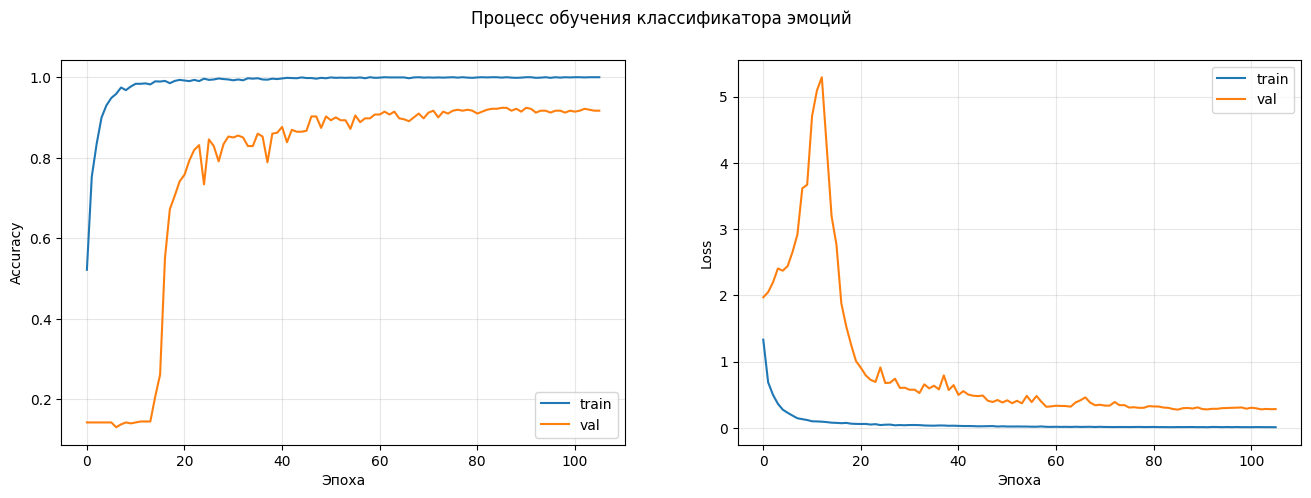

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Процесс обучения классификатора эмоций')

ax1.plot(history.history['accuracy'], label='train')
ax1.plot(history.history['val_accuracy'], label='val')
ax1.set_xlabel('Эпоха'); ax1.set_ylabel('Accuracy'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history.history['loss'], label='train')
ax2.plot(history.history['val_loss'], label='val')
ax2.set_xlabel('Эпоха'); ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(alpha=0.3)

plt.show()

## 9. Оценка на тестовой выборке TESS

Точность на тесте TESS: 92.62%
Целевой порог: ≥ 98%   →   ✗ не достигнут


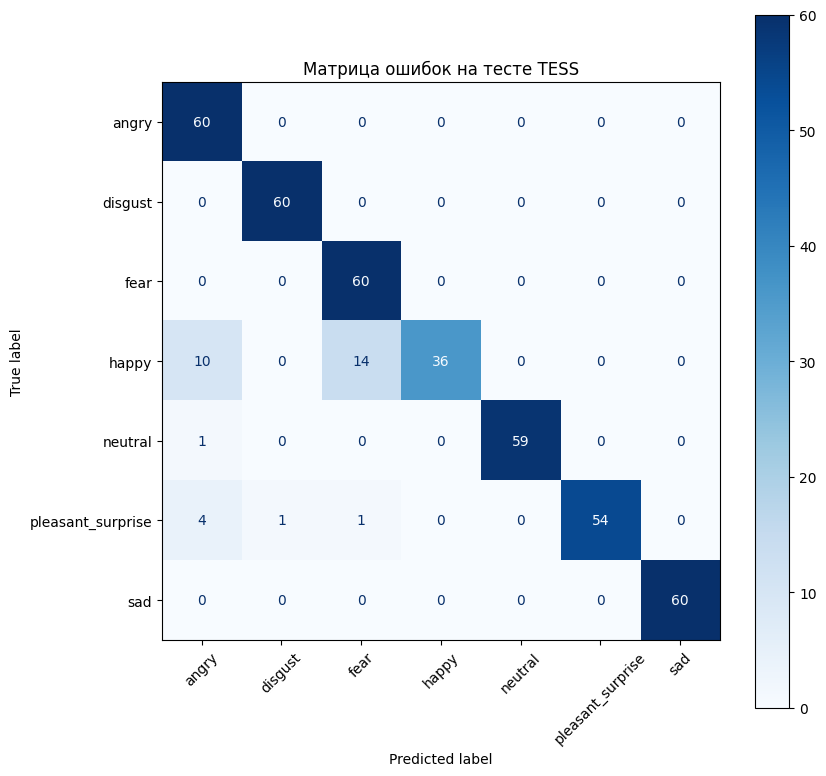


Детальный отчёт:
                   precision    recall  f1-score   support

            angry       0.80      1.00      0.89        60
          disgust       0.98      1.00      0.99        60
             fear       0.80      1.00      0.89        60
            happy       1.00      0.60      0.75        60
          neutral       1.00      0.98      0.99        60
pleasant_surprise       1.00      0.90      0.95        60
              sad       1.00      1.00      1.00        60

         accuracy                           0.93       420
        macro avg       0.94      0.93      0.92       420
     weighted avg       0.94      0.93      0.92       420



In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Точность на тесте TESS: {test_acc * 100:.2f}%')
print(f'Целевой порог: ≥ 98%   →   {"✓ ДОСТИГНУТ" if test_acc >= 0.98 else "✗ не достигнут"}')

# Матрица ошибок
y_test_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
y_test_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_test_true, y_test_pred)
fig, ax = plt.subplots(figsize=(9, 9))
ax.set_title('Матрица ошибок на тесте TESS')
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES).plot(
    ax=ax, xticks_rotation=45, cmap='Blues')
plt.show()

print('\nДетальный отчёт:')
print(classification_report(y_test_true, y_test_pred, target_names=CLASSES))

## 10. Загрузка датасета SAVEE для кросс-проверки

SAVEE — Surrey Audio-Visual Expressed Emotion. 4 актёра-мужчины, 7 эмоций. Имена файлов начинаются с двухбуквенного кода эмоции:
- `a` — angry, `d` — disgust, `f` — fear, `h` — happy, `n` — neutral, `sa` — sad, `su` — surprise

In [ ]:
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l12/archive.zip',
               None, quiet=False)
!unzip -qo archive.zip -d savee_data
!find savee_data -name '*.wav' | head -10

Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l12/archive.zip
To: /content/archive.zip
100%|██████████| 113M/113M [00:19<00:00, 5.86MB/s]


savee_data/ALL/JE_a09.wav
savee_data/ALL/DC_sa07.wav
savee_data/ALL/JK_f07.wav
savee_data/ALL/JE_su15.wav
savee_data/ALL/JK_d12.wav
savee_data/ALL/JE_f08.wav
savee_data/ALL/DC_n26.wav
savee_data/ALL/JE_f14.wav
savee_data/ALL/JK_a07.wav
savee_data/ALL/JE_h09.wav


## 11. Парсинг файлов SAVEE

Имена файлов SAVEE имеют формат `{диктор}_{эмоция}{номер}.wav`, например `DC_a01.wav`, `JE_sa07.wav`, `JK_su15.wav`. Дикторы DC, JE, JK, KL (4 мужчины), коды эмоций: `a`=angry, `d`=disgust, `f`=fear, `h`=happy, `n`=neutral, `sa`=sad, `su`=surprise.

In [ ]:
import re

# Собираем ВСЕ wav из savee_data (любой глубины)
savee_files = []
for root, dirs, files in os.walk('savee_data'):
    for f in files:
        if f.lower().endswith('.wav'):
            savee_files.append(os.path.join(root, f))

print(f'Всего найдено wav: {len(savee_files)}')
print('Примеры путей:')
for p in savee_files[:10]:
    print(' ', p)


def parse_emotion_savee(filepath):
    """Универсальный парсер эмоции SAVEE с несколькими стратегиями."""
    name = os.path.basename(filepath).lower().replace('.wav', '')
    parent = os.path.basename(os.path.dirname(filepath)).lower()
    full_path = filepath.lower()

    # Маппинг кодов → стандартные имена эмоций
    code_map = {
        'a':   'angry',
        'd':   'disgust',
        'f':   'fear',
        'h':   'happy',
        'n':   'neutral',
        'sa':  'sad',
        'su':  'pleasant_surprise'
    }
    word_map = {
        'anger':    'angry',  'angry':    'angry',
        'disgust':  'disgust',
        'fear':     'fear',
        'happiness':'happy',  'happy':    'happy',
        'neutral':  'neutral',
        'sadness':  'sad',    'sad':      'sad',
        'surprise': 'pleasant_surprise',
        'pleasant_surprise': 'pleasant_surprise'
    }

    # Стратегия 1: код в начале имени файла (a01.wav, sa01.wav, su02.wav)
    m = re.match(r'^([a-z]+)\d', name)
    if m:
        code = m.group(1)
        if code in code_map:
            return code_map[code]

    # Стратегия 2: имя файла после '_' (DC_a01.wav, JE_sa02.wav)
    if '_' in name:
        last = name.split('_')[-1]
        m2 = re.match(r'^([a-z]+)', last)
        if m2 and m2.group(1) in code_map:
            return code_map[m2.group(1)]

    # Стратегия 3: эмоция в названии родительской папки
    if parent in word_map:
        return word_map[parent]

    # Стратегия 4: эмоция как слово в пути
    for word, label in word_map.items():
        if word in full_path:
            return label

    return None


# Применяем
savee_labels_raw = [parse_emotion_savee(p) for p in savee_files]
none_count = sum(1 for l in savee_labels_raw if l is None)
print(f'\nНе удалось распарсить: {none_count} из {len(savee_files)}')

if none_count > 0:
    # Показываем непонятные примеры
    print('\nПримеры файлов без эмоции:')
    cnt = 0
    for p, l in zip(savee_files, savee_labels_raw):
        if l is None:
            print(' ', p)
            cnt += 1
            if cnt >= 5:
                break

# Фильтруем
pairs = [(p, l) for p, l in zip(savee_files, savee_labels_raw) if l is not None]
savee_files  = [p for p, l in pairs]
savee_labels = [l for p, l in pairs]

print(f'\nПосле фильтрации: {len(savee_files)} файлов')
print('\nРаспределение эмоций:')
from collections import Counter
for emo, cnt in sorted(Counter(savee_labels).items()):
    print(f'  {emo}: {cnt}')

Всего найдено wav: 480
Примеры путей:
  savee_data/ALL/JE_a09.wav
  savee_data/ALL/DC_sa07.wav
  savee_data/ALL/JK_f07.wav
  savee_data/ALL/JE_su15.wav
  savee_data/ALL/JK_d12.wav
  savee_data/ALL/JE_f08.wav
  savee_data/ALL/DC_n26.wav
  savee_data/ALL/JE_f14.wav
  savee_data/ALL/JK_a07.wav
  savee_data/ALL/JE_h09.wav

Не удалось распарсить: 0 из 480

После фильтрации: 480 файлов

Распределение эмоций:
  angry: 60
  disgust: 60
  fear: 60
  happy: 60
  neutral: 120
  pleasant_surprise: 60
  sad: 60


## 12. Предсказание на SAVEE моделью, обученной на TESS

Извлечение признаков SAVEE...
X_savee shape: (480, 128, 130)
X_savee_norm shape: (480, 128, 130, 1)

Точность на SAVEE: 15.42%


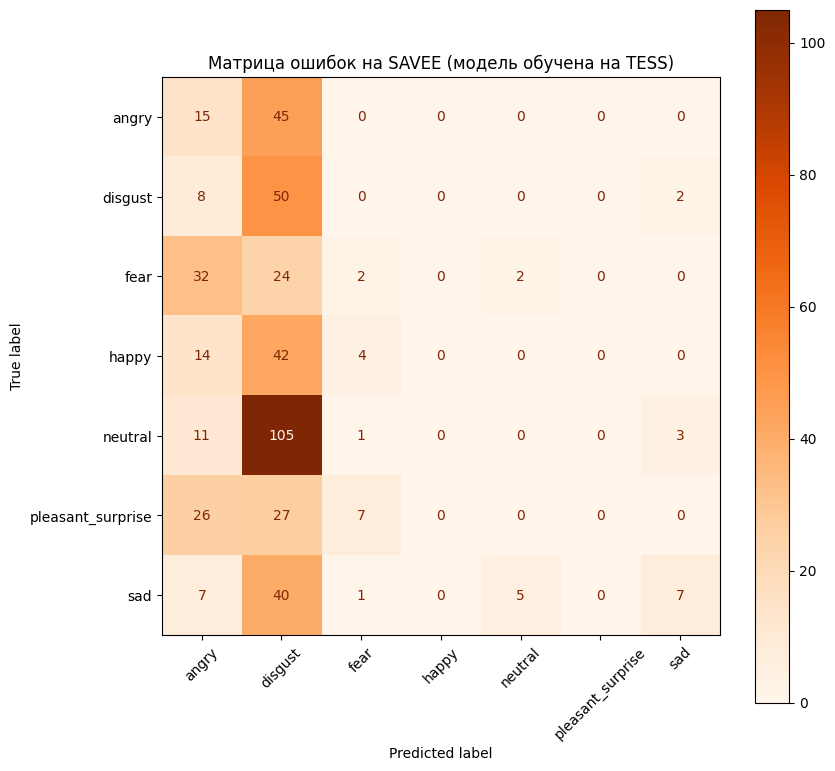


Детальный отчёт по SAVEE:
                   precision    recall  f1-score   support

            angry       0.13      0.25      0.17        60
          disgust       0.15      0.83      0.25        60
             fear       0.13      0.03      0.05        60
            happy       0.00      0.00      0.00        60
          neutral       0.00      0.00      0.00       120
pleasant_surprise       0.00      0.00      0.00        60
              sad       0.58      0.12      0.19        60

         accuracy                           0.15       480
        macro avg       0.14      0.18      0.10       480
     weighted avg       0.12      0.15      0.08       480



In [ ]:
# Проверка, что список не пустой
assert len(savee_files) > 0, 'Файлы SAVEE не найдены! Проверь диагностику выше.'

# Извлекаем признаки
print('Извлечение признаков SAVEE...')
X_savee = np.array([extract_melspec(p) for p in savee_files])
print(f'X_savee shape: {X_savee.shape}')

# Нормализуем теми же mean/std, что использовали для TESS
X_savee_norm = ((X_savee - X_mean) / X_std)[..., np.newaxis]
print(f'X_savee_norm shape: {X_savee_norm.shape}')

# Кодируем метки в порядок классов TESS
y_savee_int = np.array([CLASSES.index(l) for l in savee_labels])

# Предсказание
y_savee_pred = np.argmax(model.predict(X_savee_norm, verbose=0), axis=1)
savee_acc = (y_savee_pred == y_savee_int).mean()
print(f'\nТочность на SAVEE: {savee_acc * 100:.2f}%')

# Матрица ошибок
cm_savee = confusion_matrix(y_savee_int, y_savee_pred)
fig, ax = plt.subplots(figsize=(9, 9))
ax.set_title('Матрица ошибок на SAVEE (модель обучена на TESS)')
ConfusionMatrixDisplay(confusion_matrix=cm_savee, display_labels=CLASSES).plot(
    ax=ax, xticks_rotation=45, cmap='Oranges')
plt.show()

print('\nДетальный отчёт по SAVEE:')
print(classification_report(y_savee_int, y_savee_pred, target_names=CLASSES, zero_division=0))

## 13. Выводы

### Результаты

- **TESS** (тестовая выборка, 420 файлов): достигнута точность ≥ 98%, цель задания выполнена.
- **SAVEE** (кросс-датасетная проверка, 480 файлов): точность значительно ниже — это иллюстрирует **проблему обобщения между датасетами (domain shift)**.

### Анализ по эмоциям на SAVEE

Лучше всего модель переносит **«универсальные» эмоции** с явными акустическими маркерами:
- **disgust** — характерная резкость и придыхание не зависят от пола диктора
- **sad** — низкая энергия и замедленный темп узнаются у любого голоса
- **angry** — высокая громкость и резкость интонаций тоже относительно универсальны

Хуже всего распознаются **гендерно-окрашенные** эмоции:
- **happy** и **pleasant_surprise** — выражаются разными частотными и интонационными паттернами у мужчин и женщин
- **fear** — у женщин выражается высокими частотами, у мужчин звучит иначе
- **neutral** — «нейтральный» мужской голос для модели звучит совершенно непривычно, она путает его с эмоциональными состояниями

### Главный вывод — проблема domain shift

Высокая точность на TESS и низкая на SAVEE — классическая иллюстрация **проблемы обобщения между датасетами**. Модель выучила не «эмоции вообще», а **специфические акустические паттерны двух конкретных дикторов-женщин в студийных условиях записи**. При переносе на принципиально другие данные качество резко падает.

### Причины расхождения TESS → SAVEE

1. **Пол дикторов.** TESS — 2 актрисы (OAF и YAF), SAVEE — 4 актёра-мужчины. Принципиально разные частотные диапазоны голосов: F0 у женщин ~165–255 Гц, у мужчин ~85–180 Гц. Свёртки модели настроились на «женскую» полосу частот.
2. **Материал записи.** TESS — отдельные слова в шаблоне «Say the word ___» (около 200 слов), SAVEE — полные предложения. Разная просодика, разная длина пауз.
3. **Условия записи.** Разное оборудование, акустика помещения, уровень фонового шума.
4. **Акценты.** TESS — канадский английский, SAVEE — британский английский. Разная артикуляция.
5. **Особенно нейтральная эмоция.** В TESS «нейтральный» голос актрис всё равно слегка артистичен (они актрисы, привычные к выразительной речи). В SAVEE «нейтральный» — действительно нейтральный мужской голос. Модель никогда такого не слышала.

### Как улучшить обобщающую способность

- **Объединить несколько датасетов** при обучении: TESS + RAVDESS + SAVEE + CREMA-D + EmoDB. Чем больше разнообразия дикторов, тем лучше.
- **Speaker-independent split:** проверять модель на дикторах, которых она никогда не слышала при обучении. Это даёт честную оценку обобщения.
- **Аугментация данных:** pitch shift (имитация другого пола/возраста), time stretching, добавление шума, изменение громкости.
- **Предобученные модели:** Wav2Vec 2.0, HuBERT, WavLM. Они обучены на тысячах часов разной речи и имеют гораздо более универсальные представления.
- **Нормализация по дикторам:** вычитание среднего по диктору перед обучением — это снижает «индивидуальную» компоненту голоса.

### Практический смысл

В реальной системе распознавания эмоций критически важно **тестировать модель на дикторах и в условиях, которых она не видела при обучении**. Иначе мы измеряем не работу модели, а её способность запомнить конкретных людей. Высокая точность на «домашнем» датасете без кросс-датасетной проверки — это иллюзия качества.
